# Analytical Power Analysis

## Setup

In [ ]:

library(here)


here() starts at C:/Users/pablo/OneDrive/Github/cfa-power

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

...

The following object is masked from 'package:lavaan':

    inspect


Attaching package: 'dplyr'

The following object is masked from 'package:MASS':

    select

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

## Computing model degrees of freedom

The degrees of freedom are critical for the analytical approach because power is computed from the central and non-central χ² distributions, both parameterized by df.

In [ ]:

# Method 1: Generate data from the population model and fit the analysis model
sim_data <- lavaan::simulateData(popModel, sample.nobs = 50)
fit_temp <- lavaan::cfa(analyzeModel, data = sim_data, std.lv = TRUE)
df_model <- lavaan::fitMeasures(fit_temp, "df")

cat("Model degrees of freedom (via lavaan):", df_model, "\n")


Model degrees of freedom (via lavaan): 245 

Unique covariance elements: 300 

Model df: 245 

## A priori power analysis: Determine N

### Model-free approach (RMSEA-based) with semPower

Given the model df and a target RMSEA of 0.05, how many observations are needed for 80% power to detect misfit?


 semPower: A priori power analysis
                                   
 F0                        0.612500
 RMSEA                     0.050000
 Mc                        0.736203
                                   
 df                        245     
 Required Num Observations 100     
                                   
 Critical Chi-Square       282.5114
 NCP                       60.63750
 Alpha                     0.050000
 Beta                      0.198392
 Power (1 - Beta)          0.801608
 Implied Alpha/Beta Ratio  0.252026

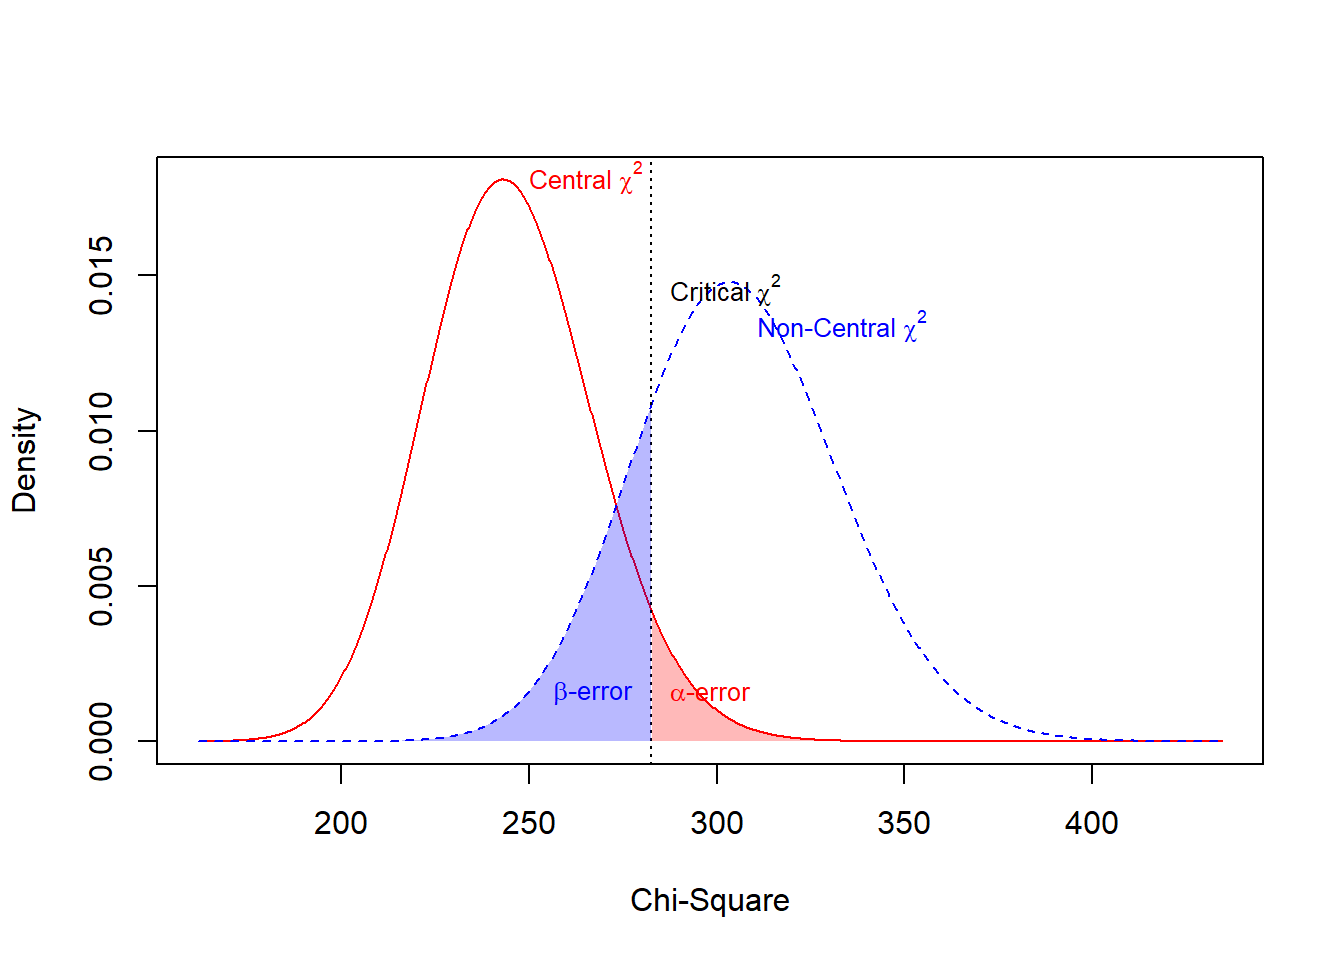

In [ ]:

ap_rmsea <- semPower::semPower.aPriori(
  effect         = 0.05,
  effect.measure = "RMSEA",
  alpha          = ALPHA,
  power          = POWER_TARGET,
  df             = df_model
)

summary(ap_rmsea)


### A priori N with semTools

Cross-validation: semTools uses the same underlying χ² approach and should yield concordant results.

In [ ]:

n_semtools <- semTools::findRMSEAsamplesize(
  rmsea0 = 0.05,    # RMSEA under H1 (the effect to detect)
  rmseaA = 0,       # RMSEA under H0 (perfect fit)
  df     = df_model,
  power  = POWER_TARGET,
  alpha  = ALPHA
)

cat("Required N (semTools):", n_semtools, "\n")


Required N (semTools): 102 

## Post hoc power analysis: Achieved power with N = 1047

### With semPower


 semPower: Post hoc power analysis
                                      
 F0                       0.612500    
 RMSEA                    0.050000    
 Mc                       0.736203    
                                      
 df                       245         
 Num Observations         1047        
 NCP                      640.6750    
                                      
 Critical Chi-Square      282.5114    
 Alpha                    0.050000    
 Beta                     3.070697e-47
 Power (1 - Beta)         > 0.9999    
 Implied Alpha/Beta Ratio 1.628295e+45

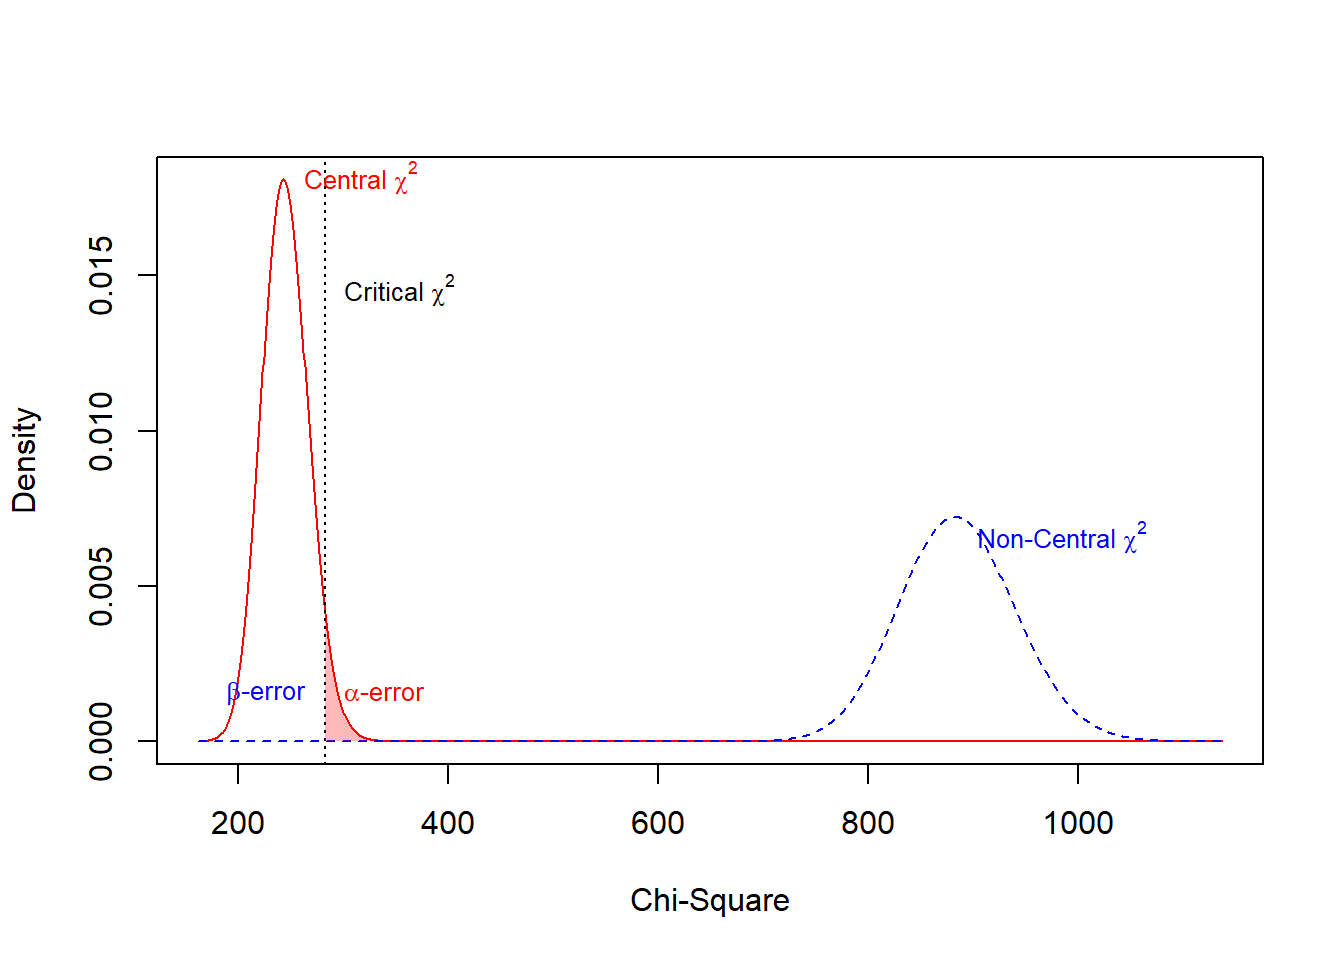

In [ ]:

ph_sempower <- semPower::semPower.postHoc(
  effect         = 0.05,
  effect.measure = "RMSEA",
  alpha          = ALPHA,
  N              = N_EMPIRICAL,
  df             = df_model
)

summary(ph_sempower)


### With semTools

In [ ]:

power_semtools <- semTools::findRMSEApower(
  rmsea0 = 0.05,
  rmseaA = 0,
  df     = df_model,
  n      = N_EMPIRICAL,
  alpha  = ALPHA
)

cat("Achieved power (semTools):", round(power_semtools, 4), "\n")


Achieved power (semTools): 1 

## Power curves

### Power by sample size

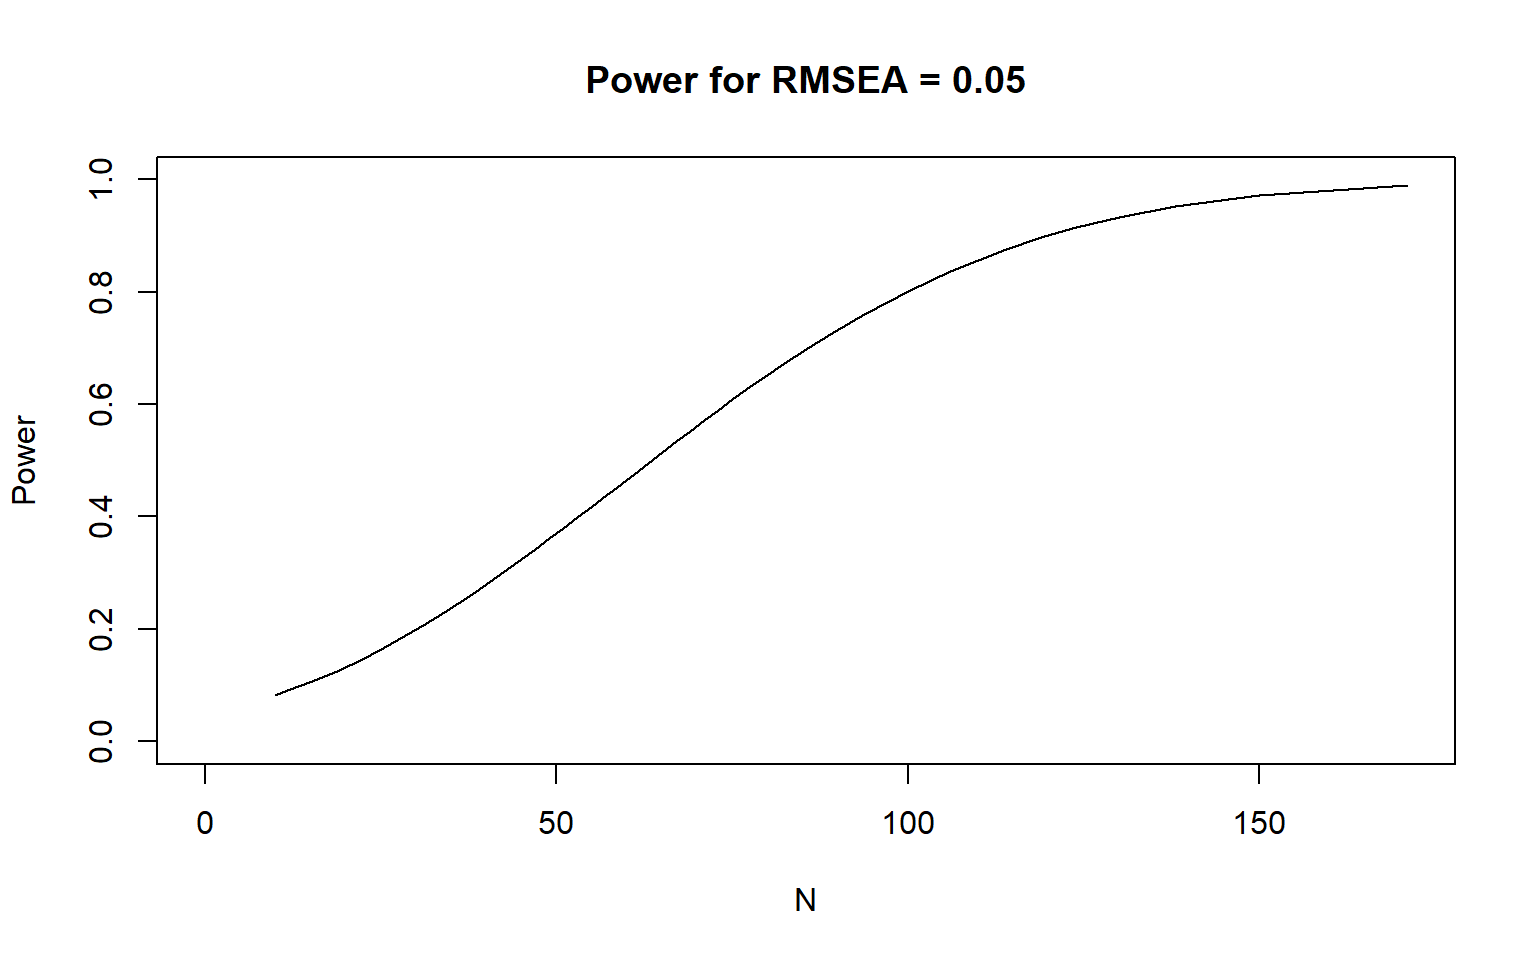

In [ ]:

semPower::semPower.powerPlot.byN(
  effect         = 0.05,
  effect.measure = "RMSEA",
  alpha          = ALPHA,
  df             = df_model,
  power.min      = 0.05,
  power.max      = 0.99
)


### Power by effect size

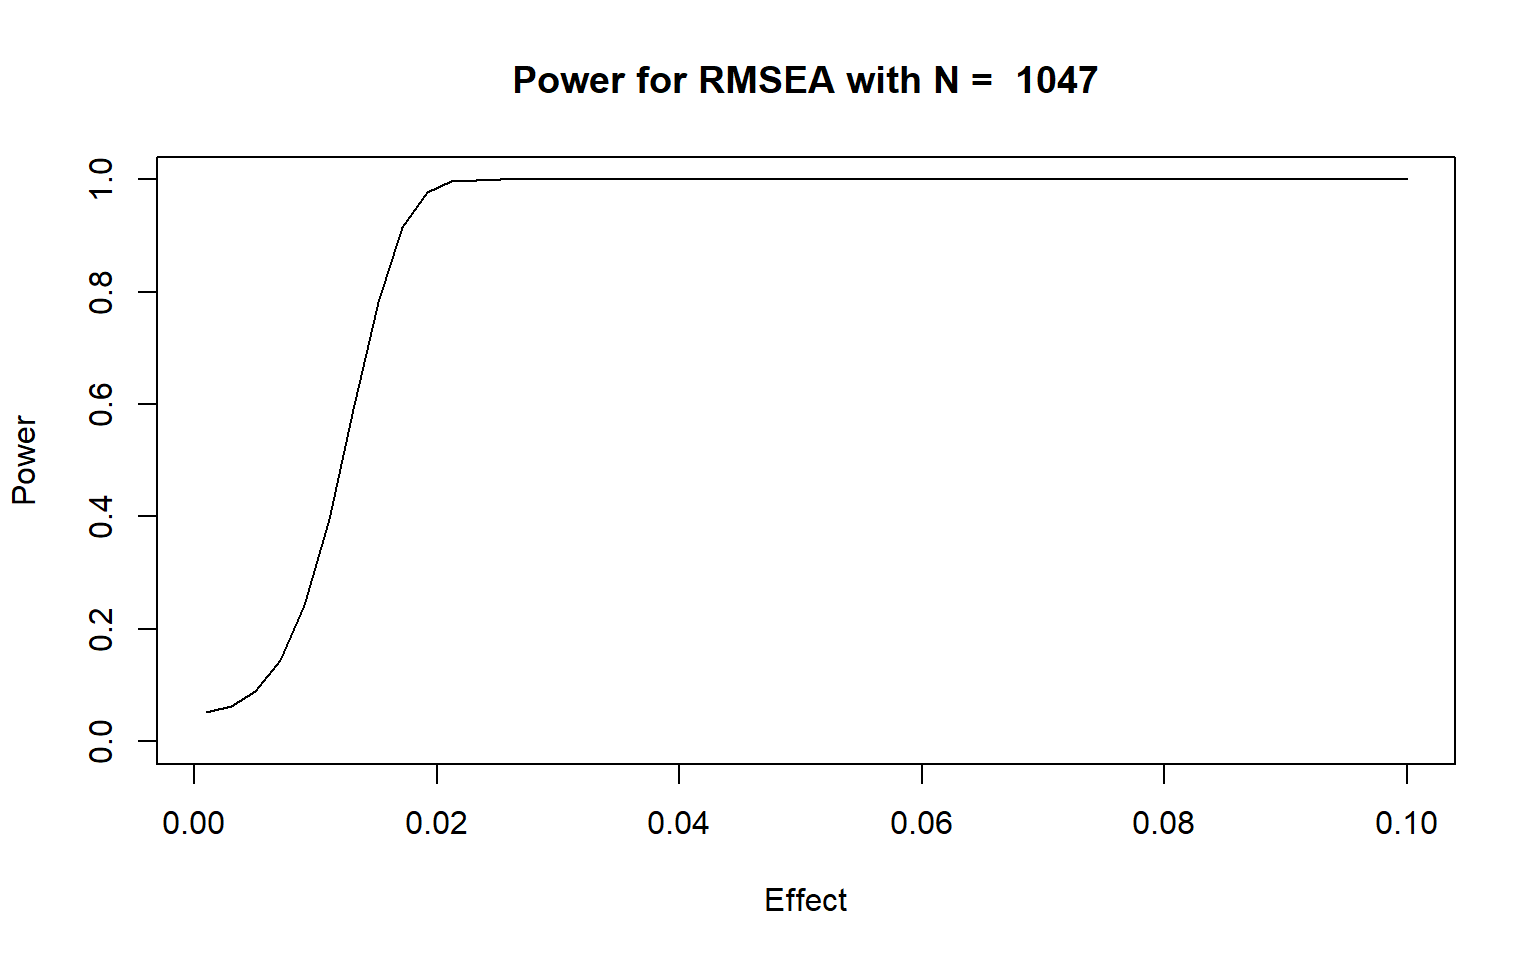

In [ ]:

semPower::semPower.powerPlot.byEffect(
  effect.measure = "RMSEA",
  alpha          = ALPHA,
  N              = N_EMPIRICAL,
  df             = df_model,
  effect.min     = 0.001,
  effect.max     = 0.10
)


## Summary table

In [ ]:

# Helper to ensure length-1 numeric
safe_num <- function(x) if(length(x) == 0 || is.null(x)) NA else as.numeric(x)[1]

analytical_summary <- data.frame(
  Method = c(
    "semPower a priori (RMSEA ≥ .05)",
    "semTools a priori (RMSEA ≥ .05)",
    "semPower post hoc (N = 1047)",
    "semTools post hoc (N = 1047)"
  ),
  `N Required` = c(
    safe_num(ap_rmsea$requiredN),
    safe_num(n_semtools),
    N_EMPIRICAL,
    N_EMPIRICAL
  ),
  `Power` = c(
    round(safe_num(ap_rmsea$power), 4),
    POWER_TARGET,
    round(safe_num(ph_sempower$power), 4),
    round(safe_num(power_semtools), 4)
  ),
  df = rep(safe_num(df_model), 4),
  check.names = FALSE
)

kable(analytical_summary, align = "lccc")


  Method                             N Required   Power   df
  --------------------------------- ------------ ------- -----
  semPower a priori (RMSEA ≥ .05)       100        NA     245
  semTools a priori (RMSEA ≥ .05)       102        0.8    245
  semPower post hoc (N = 1047)          1047       1.0    245
  semTools post hoc (N = 1047)          1047       1.0    245
